# 03 — EDA (Análisis Exploratorio de Datos)

**Objetivo:** entender el negocio con datos para tomar decisiones informadas sobre el modelado.

El propósito de este notebook es responder preguntas concretas sobre el comportamiento del negocio:

- ¿Cuál es el patrón de ventas diarias? ¿Hay estacionalidad semanal, mensual, por temporada?
- ¿Qué variables correlacionan con las ventas? ¿Temperatura, festivos, día de la semana?
- ¿Cómo se comportan las reservas respecto a los tickets reales?
- ¿Qué artículos concentran el 80% de la facturación?
- ¿Hay diferencias relevantes entre turno de comida y cena?

Las respuestas a estas preguntas definen qué features entran al modelo y con qué forma.


*Arquitectura Medallion: Bronze → Silver → **Gold***

### 0. Setup

Imports, rutas, carga de los parquets de Silver. Una sola celda de configuración compartida.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Rutas del proyecto ────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

for p in [str(PROJECT_ROOT), str(PROJECT_ROOT / 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

DATA_DIR    = PROJECT_ROOT / 'data'
BRONZE_SNAP = DATA_DIR / 'bronze' / 'snapshots'
SILVER_SNAP = DATA_DIR / 'silver' / 'snapshots'
GOLD_DIR    = DATA_DIR / 'gold'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures' / 'eda'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'Bronze snaps : {BRONZE_SNAP}')
print(f'Silver snaps : {SILVER_SNAP}')
print(f'Gold dir     : {GOLD_DIR}')
print(f'Figures dir  : {FIGURES_DIR}')

Project root : /Users/aa/Desktop/TFM/Código/TFM-Hosteleria-AI
Bronze snaps : /Users/aa/Desktop/TFM/Código/TFM-Hosteleria-AI/data/bronze/snapshots
Silver snaps : /Users/aa/Desktop/TFM/Código/TFM-Hosteleria-AI/data/silver/snapshots
Gold dir     : /Users/aa/Desktop/TFM/Código/TFM-Hosteleria-AI/data/gold
Figures dir  : /Users/aa/Desktop/TFM/Código/TFM-Hosteleria-AI/results/figures/eda


### 1. Visión general de los datos Silver
Tabla resumen de todos los datasets: filas, columnas, cobertura temporal. El equivalente al `audit_dataset` de la depuración, pero aquí como punto de partida descriptivo, no como diagnóstico de calidad (eso ya está hecho).

In [8]:
# ── Carga desde Silver ────────────────────────────────────────────────────────
df_tickets       = pd.read_parquet(SILVER_SNAP / 'tickets_silver.parquet')
df_ventas        = pd.read_parquet(SILVER_SNAP / 'ventas_silver.parquet')
df_reservas      = pd.read_parquet(SILVER_SNAP / 'reservas_silver.parquet')
df_tips          = pd.read_parquet(SILVER_SNAP / 'tips_silver.parquet')
df_artic         = pd.read_parquet(SILVER_SNAP / 'articulos_silver.parquet')
df_depart        = pd.read_parquet(SILVER_SNAP / 'departamentos_silver.parquet')
df_menu          = pd.read_parquet(SILVER_SNAP / 'menu_silver.parquet')
df_festivos      = pd.read_parquet(SILVER_SNAP / 'festivos_silver.parquet')
df_eventos       = pd.read_parquet(SILVER_SNAP / 'eventos_silver.parquet')
df_meteo_diaria  = pd.read_parquet(SILVER_SNAP / 'meteo_diaria_silver.parquet')
df_meteo_horaria = pd.read_parquet(SILVER_SNAP / 'meteo_horaria_silver.parquet')
df_facturas      = pd.read_parquet(SILVER_SNAP / 'facturas_silver.parquet')
# df_total_articles = pd.read_parquet(SILVER_SNAP / 'total_articles_silver.parquet')

print('Datasets cargados desde Silver:')
for nombre, df in {
    'tickets': df_tickets, 'ventas': df_ventas, 'reservas': df_reservas,
    'tips': df_tips, 'articulos': df_artic, 'departamentos': df_depart,
    'menu': df_menu, 'festivos': df_festivos, 'eventos': df_eventos,
    'meteo_diaria': df_meteo_diaria, 'meteo_horaria': df_meteo_horaria,
    'facturas': df_facturas,
    # 'total_articles': df_total_articles
}.items():
    print(f'  ✓  {nombre:<20} {len(df):>6,} filas  x  {len(df.columns)} columnas')

Datasets cargados desde Silver:
  ✓  tickets               6,709 filas  x  14 columnas
  ✓  ventas                5,532 filas  x  14 columnas
  ✓  reservas             21,289 filas  x  20 columnas
  ✓  tips                  1,697 filas  x  12 columnas
  ✓  articulos               405 filas  x  4 columnas
  ✓  departamentos            23 filas  x  3 columnas
  ✓  menu                    405 filas  x  3 columnas
  ✓  festivos                 24 filas  x  4 columnas
  ✓  eventos                  78 filas  x  20 columnas
  ✓  meteo_diaria            921 filas  x  10 columnas
  ✓  meteo_horaria        22,104 filas  x  4 columnas
  ✓  facturas                 72 filas  x  18 columnas


In [9]:
def audit_dataset(nombre, df, col_fecha=None):
    fecha_min = pd.NaT
    fecha_max = pd.NaT
    if col_fecha is not None and col_fecha in df.columns:
        col = pd.to_datetime(df[col_fecha], errors='coerce')
        fecha_min = col.min()
        fecha_max = col.max()
    return {
        'dataset':            nombre,
        'filas':              len(df),
        'columnas':           len(df.columns),
        'nulos_pct_max':      round(df.isnull().mean().max() * 100, 2),
        'duplicados_exactos': int(df.duplicated().sum()),
        'fecha_min':          fecha_min,
        'fecha_max':          fecha_max,
    }

auditoria = pd.DataFrame([
    audit_dataset('tickets',       df_tickets,       col_fecha='date'),
    audit_dataset('ventas',        df_ventas,        col_fecha='report_start'),
    audit_dataset('reservas',      df_reservas,      col_fecha='reservation_datetime'),
    audit_dataset('tips',          df_tips,          col_fecha=None),
    audit_dataset('articulos',     df_artic,         col_fecha=None),  # catálogo estático
    audit_dataset('departamentos', df_depart,        col_fecha=None),  # catálogo estático
    audit_dataset('menu',          df_menu,          col_fecha=None),  # catálogo estático
    audit_dataset('festivos',      df_festivos,      col_fecha='fecha'),
    audit_dataset('eventos',       df_eventos,       col_fecha='fecha_inicio'),
    audit_dataset('meteo_diaria',  df_meteo_diaria,  col_fecha='date'),
    audit_dataset('meteo_horaria', df_meteo_horaria, col_fecha='datetime'),
    audit_dataset('facturas',      df_facturas,      col_fecha='fecha'), # dataset nuevo
    # audit_dataset('total_articles',      df_total_articles,      col_fecha='fecha') excluido: agregado global sin granularidad diaria,
    # no aporta al EDA orientado a series temporales. Cargar explícitamente si se necesita.
])

display(auditoria)

,dataset,filas,columnas,nulos_pct_max,duplicados_exactos,fecha_min,fecha_max
0,tickets,6709,14,0.00,0,2025-10-02 00:00:00,2026-07-09 00:00:00
1,ventas,5532,14,0.00,0,2025-10-01 00:00:00,2026-07-06 00:00:00
2,reservas,21289,20,6.78,0,2022-11-10 13:45:00,2026-07-08 21:15:00
3,tips,1697,12,0.00,0,NaT,NaT
4,articulos,405,4,0.00,0,NaT,NaT
5,departamentos,23,3,0.00,0,NaT,NaT
6,menu,405,3,0.00,0,NaT,NaT
7,festivos,24,4,0.00,0,2025-01-01 00:00:00,2026-12-25 00:00:00
8,eventos,78,20,0.00,0,2025-10-10 00:00:00,2026-09-16 00:00:00
9,meteo_diaria,921,10,0.00,0,2024-01-01 00:00:00,2026-07-09 00:00:00


### 2. Análisis de la variable objetivo: ingresos diarios
La serie temporal de facturación agregada por día es el núcleo del TFM. Todo lo demás es contexto explicativo de esta variable.

- Evolución temporal de facturación diaria (tickets + ventas)
- Distribución del importe por ticket
- Detección visual de outliers y comportamientos anómalos
- Patrón por día de la semana y por turno

La facturación diaria es la variable que el modelo deberá predecir.

En esta sección construimos la serie temporal agregada, analizamos su distribución, identificamos patrones temporales y detectamos anomalías.

Las fuentes utilizadas son `df_tickets` (un registro por ticket) y `df_ventas` (un registro por artículo vendido). Ambas cubren el período 2025-10-01 / 2026-07-09.

#### 2.1. Construcción de la serie diaria

In [11]:
# Agregamos df_tickets a nivel diario.
# document_total es el importe total del ticket — es la variable objetivo.
# Usamos 'date' como columna de fecha (ya depurada en Silver).

ingresos_diarios = (
    df_tickets
    .groupby('date')
    .agg(
        num_tickets      = ('document_id',    'nunique'),
        facturacion      = ('document_total', 'sum'),
        ticket_medio     = ('document_total', 'mean'),
        ticket_mediano   = ('document_total', 'median'),
    )
    .reset_index()
    .rename(columns={'date': 'fecha'})
    .sort_values('fecha')
)

print(f"Período: {ingresos_diarios['fecha'].min()}  →  {ingresos_diarios['fecha'].max()}")
print(f"Días con actividad : {len(ingresos_diarios)}")
print(f"Días totales en período: {(ingresos_diarios['fecha'].max() - ingresos_diarios['fecha'].min()).days + 1}")
print(f"\nEstadísticas de facturación diaria:")
display(ingresos_diarios['facturacion'].describe().to_frame().T.round(2))

Período: 2025-10-02 00:00:00  →  2026-07-09 00:00:00
Días con actividad : 242
Días totales en período: 281

Estadísticas de facturación diaria:


,count,mean,std,min,25%,50%,75%,max
facturacion,242.0,2799.55,1346.66,637.9,1746.55,2440.93,3816.29,6785.2


La facturación diaria media es de **2.799€** (mediana 2.441€), con una desviación típica de 1.346€ — un coeficiente de variación del 48%, que indica alta dispersión. 

El rango va de 638€ a 6.785€. 

La diferencia entre media y mediana (358€) apunta a una distribución asimétrica hacia la derecha, con días de facturación excepcionalmente alta que tiran de la media hacia arriba.

#### 2.2. Días sin actividad

In [12]:
# Detectamos días del período sin ningún ticket registrado.
# Pueden ser cierres, festivos o huecos en los datos — hay que distinguirlos.

rango_completo = pd.date_range(
    start=ingresos_diarios['fecha'].min(),
    end=ingresos_diarios['fecha'].max(),
    freq='D'
)

dias_sin_actividad = rango_completo.difference(pd.to_datetime(ingresos_diarios['fecha']))

print(f"Días sin actividad: {len(dias_sin_actividad)}")
print()

# Cruzamos con festivos para clasificar cada ausencia
fechas_festivos = pd.to_datetime(df_festivos['fecha'])

for d in sorted(dias_sin_actividad):
    es_festivo = d in fechas_festivos.values
    dia_semana = d.day_name()
    nombre     = df_festivos.loc[pd.to_datetime(df_festivos['fecha']) == d, 'festivo_nombre'].values
    etiqueta   = nombre[0] if len(nombre) > 0 else ('festivo s/n' if es_festivo else 'cierre operativo')
    print(f"  {d.date()}  {dia_semana:<12}  {etiqueta}")

Días sin actividad: 39

  2025-10-06  Monday        cierre operativo
  2025-10-14  Tuesday       cierre operativo
  2025-10-20  Monday        cierre operativo
  2025-10-27  Monday        cierre operativo
  2025-11-03  Monday        cierre operativo
  2025-11-10  Monday        cierre operativo
  2025-11-17  Monday        cierre operativo
  2025-11-24  Monday        cierre operativo
  2025-12-01  Monday        cierre operativo
  2025-12-09  Tuesday       cierre operativo
  2025-12-15  Monday        cierre operativo
  2025-12-29  Monday        cierre operativo
  2026-01-07  Wednesday     cierre operativo
  2026-01-12  Monday        cierre operativo
  2026-01-19  Monday        cierre operativo
  2026-01-26  Monday        cierre operativo
  2026-02-02  Monday        cierre operativo
  2026-02-09  Monday        cierre operativo
  2026-02-16  Monday        cierre operativo
  2026-02-23  Monday        cierre operativo
  2026-03-02  Monday        cierre operativo
  2026-03-09  Monday        cie

El restaurante opera 242 de los 281 días del período (oct-25 / jul-09-26), lo que supone un 86% de días con actividad. 

Los 39 días restantes son **cierres operativos sistemáticos**, no huecos de datos: 35 de ellos caen en lunes, lo que confirma que el lunes es el día de cierre habitual del
establecimiento. Las cuatro excepciones (un martes en octubre, un martes en diciembre, un miércoles en enero y una ausencia puntual) requieren
verificación con el negocio — pueden ser cierres por vacaciones o festivos internos no documentados. 

Este patrón de cierre **debe incorporarse al modelo como variable binaria** (`es_lunes_cierre`) para evitar que el modelo intente predecir facturación en días que estructuralmente no abren.

#### 2.3. Evolución temporal

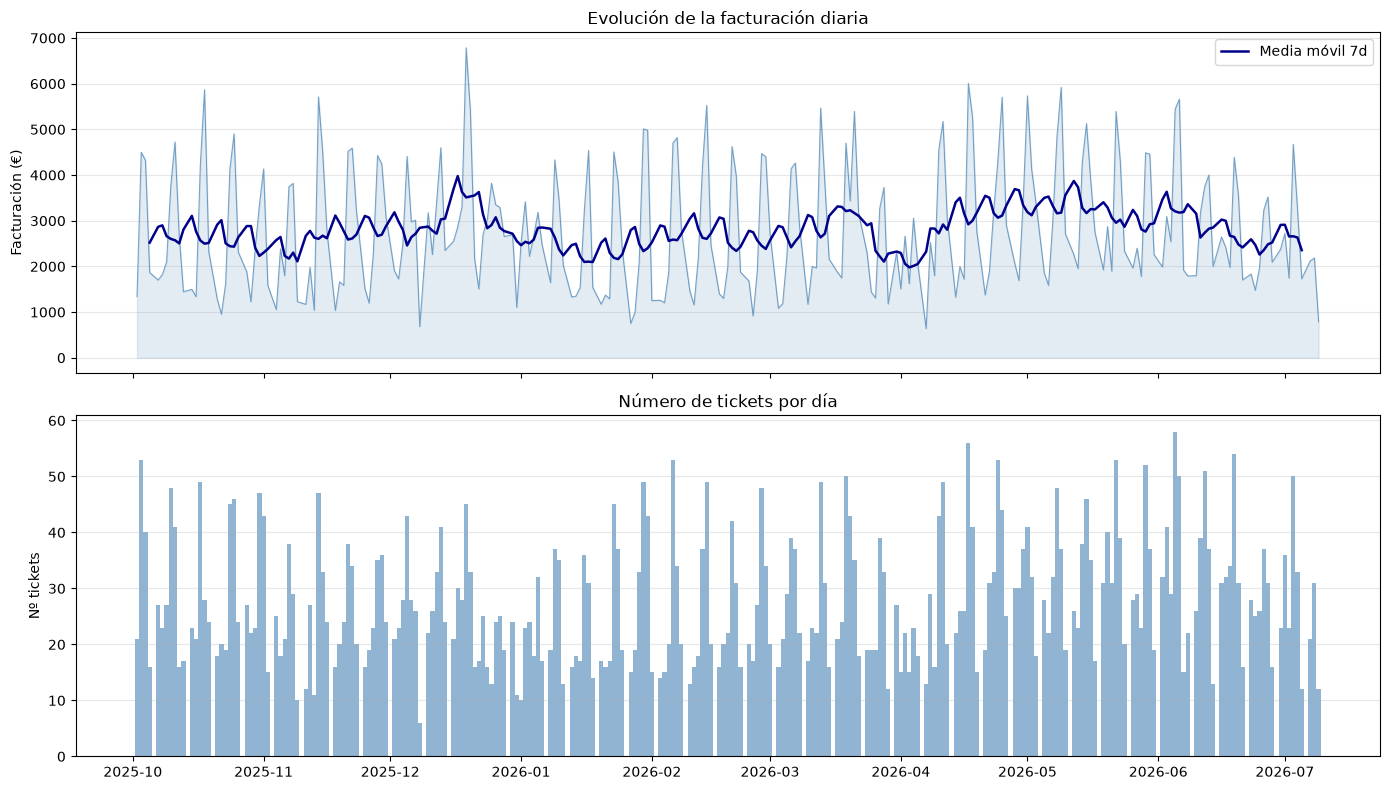

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel superior: facturación diaria
axes[0].plot(ingresos_diarios['fecha'], ingresos_diarios['facturacion'],
             color='steelblue', linewidth=0.8, alpha=0.7)
axes[0].fill_between(ingresos_diarios['fecha'], ingresos_diarios['facturacion'],
                     alpha=0.15, color='steelblue')

# Media móvil 7 días para ver tendencia sin ruido semanal
media_movil = ingresos_diarios['facturacion'].rolling(7, center=True).mean()
axes[0].plot(ingresos_diarios['fecha'], media_movil,
             color='darkblue', linewidth=1.8, label='Media móvil 7d')

axes[0].set_ylabel('Facturación (€)')
axes[0].set_title('Evolución de la facturación diaria')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Panel inferior: número de tickets
axes[1].bar(ingresos_diarios['fecha'], ingresos_diarios['num_tickets'],
            color='steelblue', alpha=0.6, width=1)
axes[1].set_ylabel('Nº tickets')
axes[1].set_title('Número de tickets por día')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'evolucion_facturacion_diaria.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
df_tickets['document_total'].value_counts().sort_index()

document_total
1.00        1
2.00        6
2.35       38
2.50        1
2.95       13
           ..
1035.00     1
1170.00     1
1344.00     1
1435.00     1
3821.65     1
Name: count, Length: 2669, dtype: int64

#### Patrón por día de la semana

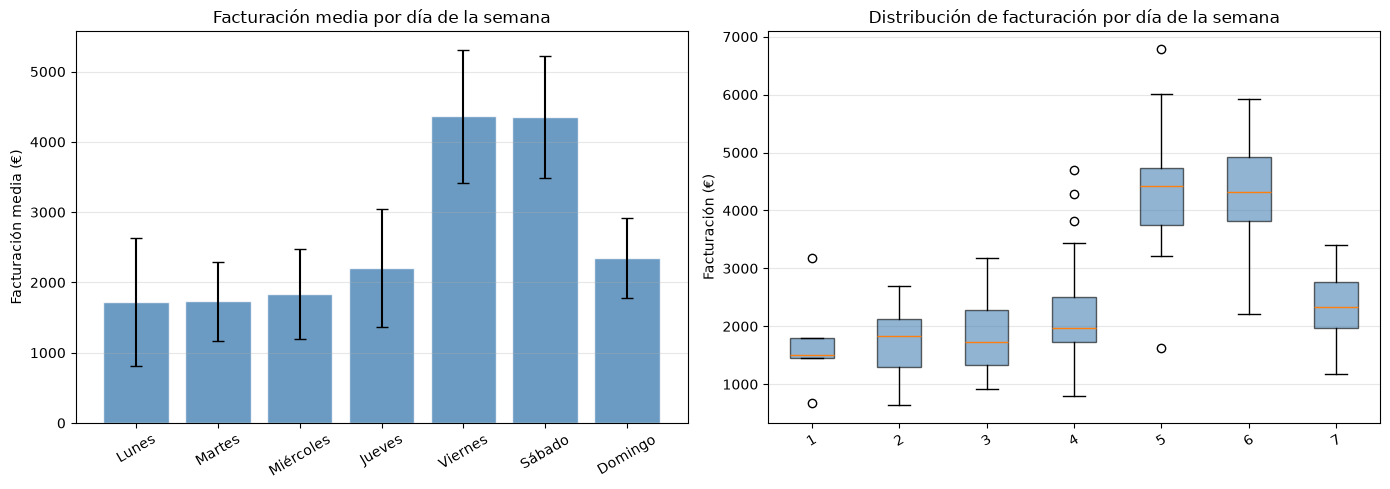

,dia_es,mean,median,std,count
0,Lunes,1720.80,1505.50,913.98,5
1,Martes,1733.10,1832.40,561.06,37
2,Miércoles,1830.59,1726.65,641.81,39
3,Jueves,2208.45,1979.50,842.90,41
4,Viernes,4365.39,4418.17,942.95,40
5,Sábado,4355.42,4316.05,861.89,40
6,Domingo,2349.78,2341.18,573.37,40


In [15]:
# Añadimos variables temporales a la serie diaria para el análisis de patrones.
ingresos_diarios['dia_semana']    = pd.to_datetime(ingresos_diarios['fecha']).dt.day_name()
ingresos_diarios['num_dia']       = pd.to_datetime(ingresos_diarios['fecha']).dt.dayofweek  # 0=lunes
ingresos_diarios['mes']           = pd.to_datetime(ingresos_diarios['fecha']).dt.month

orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
nombres_dias = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

media_por_dia = (
    ingresos_diarios
    .groupby('dia_semana')['facturacion']
    .agg(['mean','median','std','count'])
    .reindex(orden_dias)
    .reset_index()
)
media_por_dia['dia_es'] = nombres_dias

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras con media y desviación típica
axes[0].bar(media_por_dia['dia_es'], media_por_dia['mean'],
            yerr=media_por_dia['std'], capsize=4,
            color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Facturación media por día de la semana')
axes[0].set_ylabel('Facturación media (€)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

# Boxplot para ver distribución completa
data_por_dia = [
    ingresos_diarios.loc[ingresos_diarios['dia_semana'] == d, 'facturacion'].values
    for d in orden_dias
]
axes[1].boxplot(data_por_dia, label=nombres_dias, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Distribución de facturación por día de la semana')
axes[1].set_ylabel('Facturación (€)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'patron_dia_semana.png', dpi=150, bbox_inches='tight')
plt.show()

display(media_por_dia[['dia_es','mean','median','std','count']].round(2))

El patrón por día de la semana es la conclusión más relevante de esta sección y probablemente la feature más importante del modelo. Viernes y sábado facturan de media **4.365€ y 4.355€** respectivamente, más del doble que lunes-miércoles (~1.700-1.800€). El domingo (~2.350€) se sitúa en un nivel intermedio. 

La separación entre días laborables y fin de semana es limpia y consistente (la std dentro de cada día es razonable y los boxplots no se solapan entre el grupo laborable y el grupo fin de semana). **El día de la semana explicará por sí solo una fracción muy significativa de la varianza de la variable objetivo.**

Nota: los lunes tienen solo 5 observaciones (frente a ~40 del resto) porque es el día de cierre habitual. La media de lunes (1.720€) no es representativa — corresponde a los escasos lunes excepcionales en que el restaurante abrió.

#### 2.5. Patrón mensual

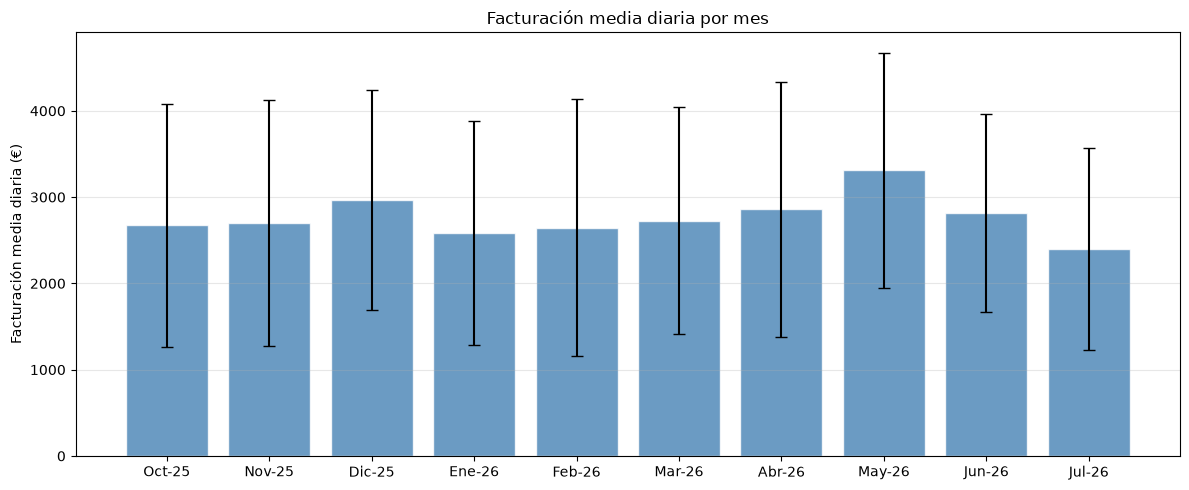

⚠️  Julio-26: solo 8 días disponibles — la media no es comparable al resto de meses.


In [17]:
# Orden cronológico explícito: el mes numérico solo no sirve porque
# el período cruza dos años (oct-25 → jul-26)
orden_meses = {10:0, 11:1, 12:2, 1:3, 2:4, 3:5, 4:6, 5:7, 6:8, 7:9}

media_por_mes = (
    ingresos_diarios
    .groupby('mes')['facturacion']
    .agg(['mean','median','std','count'])
    .reset_index()
)

nombres_meses = {10:'Oct-25', 11:'Nov-25', 12:'Dic-25',
                  1:'Ene-26',  2:'Feb-26',  3:'Mar-26',
                  4:'Abr-26',  5:'May-26',  6:'Jun-26',  7:'Jul-26'}

media_por_mes['mes_label'] = media_por_mes['mes'].map(nombres_meses)
media_por_mes['orden']     = media_por_mes['mes'].map(orden_meses)
media_por_mes = media_por_mes.sort_values('orden')

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(media_por_mes['mes_label'], media_por_mes['mean'],
       yerr=media_por_mes['std'], capsize=4,
       color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('Facturación media diaria por mes')
ax.set_ylabel('Facturación media diaria (€)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'patron_mensual.png', dpi=150, bbox_inches='tight')
plt.show()

dias_julio = media_por_mes.loc[media_por_mes['mes'] == 7, 'count'].values[0]
print(f"⚠️  Julio-26: solo {dias_julio} días disponibles — la media no es comparable al resto de meses.")

La facturación media diaria es sorprendentemente estable a lo largo de todo el período: todos los meses se sitúan entre 2.600€ y 2.800€, con la excepción de mayo-26 (~3.300€), que podría estar influenciado por eventos puntuales o una concentración de fines de semana favorable ese mes. Las barras de error son amplias y se solapan completamente entre meses, lo que indica que la varianza intramensual (dominada por el efecto día de la semana) supera con creces la varianza intermensual. Julio-26 (~2.400€) tiene datos parciales y no es comparable.

Implicación para el modelo: el mes del año no será una feature discriminante. La señal estacional relevante opera a escala semanal, no mensual. Con un único ciclo anual disponible en los datos, no es posible confirmar ni descartar estacionalidad anual.

#### 2.6. Distribución por ticket y detección de outliers

/var/folders/jf/w3c53_d13jq83wl6lx4k_1vr0000gn/T/ipykernel_14485/460861348.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_tickets['document_total'], vert=True, patch_artist=True,


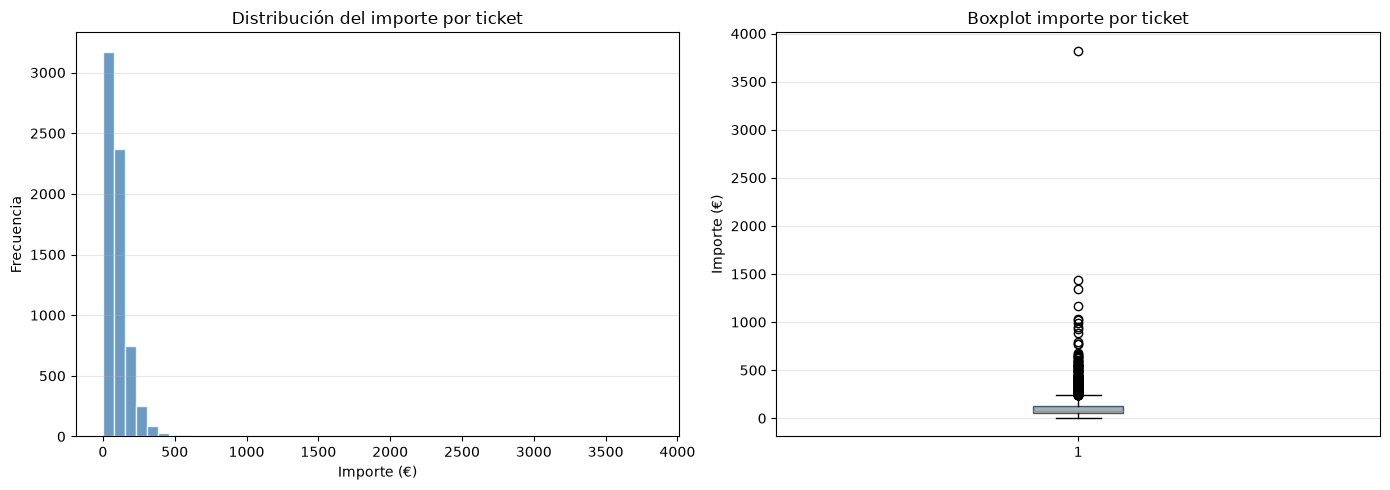

Umbral outlier (Percentil 99): 400.00 €
Tickets por encima del umbral: 67 (1.00%)


,date,document_id,document_total
449,2025-10-18,00001TM00000453,3821.65
1986,2025-12-25,00001TM00002065,1435.00
4512,2026-04-18,00001TM00004630,1344.00
1362,2025-11-28,00001TM00001431,1170.00
1609,2025-12-10,00001TM00001683,1035.00
1991,2025-12-26,00001TM00002070,1025.05
5419,2026-05-22,00001TM00005544,990.00
2123,2026-01-02,00001TM00002204,945.00
1268,2025-11-23,00001TM00001336,927.85
1972,2025-12-24,00001TM00002050,891.00


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_tickets['document_total'], bins=50,
             color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribución del importe por ticket')
axes[0].set_xlabel('Importe (€)')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.3)

# Boxplot para identificar outliers visualmente
axes[1].boxplot(df_tickets['document_total'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot importe por ticket')
axes[1].set_ylabel('Importe (€)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'distribucion_importe_ticket.png', dpi=150, bbox_inches='tight')
plt.show()

# Umbral percentil 99
lim_sup = df_tickets['document_total'].quantile(0.99)

outliers = df_tickets[df_tickets['document_total'] > lim_sup]
print(f"Umbral outlier (Percentil 99): {lim_sup:.2f} €")
print(f"Tickets por encima del umbral: {len(outliers)} ({len(outliers)/len(df_tickets)*100:.2f}%)")
display(outliers[['date','document_id','document_total']].sort_values('document_total', ascending=False).head(10))

La distribución es fuertemente asimétrica: la mayoría de tickets corresponden a consumiciones individuales o pequeños grupos (moda por debajo de 100€), mientras que la cola derecha recoge mesas grandes y eventos privados. Esta heterogeneidad es operativamente coherente para un restaurante que atiende desde un café de barra hasta cenas de grupo.

Se identifican 67 tickets (1,00%) por encima del umbral de 400€ (Percentil 99), con un máximo de 3.821€. Estos tickets no son errores — son eventos reales de alto valor que  xplican parte de los picos observados en la serie temporal diaria. **No deben eliminarse**, pero sí pueden considerarse como feature (`hay_evento_grande`) si se detecta que coinciden con eventos del calendario.

### 3. Análisis de reservas
- Volumen diario de reservas por turno y estado (confirmada, cancelada, no-show)
- Tasa de cancelación y no-show en el tiempo
- Relación reservas → comensales reales (si está disponible)
- Antelación de la reserva (creación vs. servicio)

### 4. Análisis de producto (ventas por artículo y departamento)
- Artículos y departamentos más vendidos (volumen e importe)
- Concentración: ¿cuántos artículos explican el 80% de la facturación? (Pareto)
- Estacionalidad por categoría/departamento

> ⚠️ Ojo: `total_articles` es un agregado global sin granularidad diaria. No mezclar con `ventas` sin aclarar qué se está mirando.

### 5. Análisis de propinas (tips)
- Distribución del importe de propina
- Relación propina / importe ticket (ratio)
- Variación por turno o día de la semana si está disponible vía `document_id`

### 6. Variables externas: meteorología
- Temperatura y precipitación en el período de estudio
- Correlación visual (scatter / heatmap) entre variables meteo y facturación diaria
- ¿Hay efecto diferenciado entre días de lluvia y días secos?

### 7. Variables externas: festivos y eventos
- Distribución de facturación en días festivos vs. no festivos
- Comportamiento en fechas de eventos de alto impacto (Pozuelo, La Roca)
- Comparativa visual de medias: festivo vs. laborable, evento vs. sin evento

### 8. Análisis cruzado: construcción de la tabla maestra diaria
Este paso es crítico porque es el que alimenta directamente el modelado. Se trata de unir en una sola tabla por día:

- Facturación diaria (de tickets/ventas)
- N.º reservas y comensales
- Variables meteo diarias
- Flag festivo / nombre festivo
- Flag evento / intensidad sugerida

Comprobar que no hay huecos temporales inesperados tras el cruce.

### 9. Correlaciones y selección preliminar de features
- Matriz de correlación entre facturación diaria y todas las variables numéricas disponibles
- Identificación de las variables con mayor correlación con la variable objetivo
- Primera reflexión sobre qué features tienen sentido para el modelo (justificada, no automática)

### 10. Conclusiones del EDA
Resumen breve y accionable: qué patrones se han encontrado, qué features parecen relevantes, qué limitaciones tiene el dato (cobertura temporal desde oct-2025, tamaño de muestra, ausencia de datos de personal/costes, etc.). Este apartado alimenta directamente la sección del documento final.